# Subregion Grid Mapping & Weather Data Subregion-Filter Pipeline

**Purpose:** Build a lon/lat → California subregion lookup table by spatially joining
the weather reanalysis grid against the CA subregion polygons, then apply that mapping
as a second spatial filter on every veg-filtered weather variable.

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Build Subregion Mapping** | Load shapefile, visualize polygons, spatial-join weather grid to subregions, QA assignments, drop unmatched cells, save lookup |
| **B. Apply Subregion Filter** | Batch inner-join every veg-filtered weather parquet with the subregion lookup; track missing rates before & after; save results, CSVs, and log |

**Inputs:**
- `Subregion_Data/ca_subregions_5.shp` — CA subregion polygon shapefile
- `Subregion_Data/subregion_summary.csv` — subregion metadata table
- `Clean_Data/Weather_Data/Combined_Weather_Data_w_Veg_Filter/` — veg-filtered weather parquets
- `Clean_Data/Veg_Data/lon_lat_pair_weather_match_veg_v2.parquet` — reference veg-filtered grid

**Outputs:**
- `Clean_Data/Subregion_Data/lon_lat_pair_weather_match_subregion.parquet` — grid → subregion lookup
- `Clean_Data/Weather_Data/Combined_Weather_Data_w_Veg_SubRegion_Filter/` — subregion-filtered weather parquets
- `Summary_Data/Missing_Rate/weather_data_w_veg_filter.csv` — pre-filter missing rates
- `Summary_Data/Missing_Rate/weather_data_w_veg_subregion_filter.csv` — post-filter missing rates
- `Logs/Clean_Extended_Data/filter_weather_veg_data_w_subregion_log.txt` — processing log

## 0. Configuration

Centralized path configuration — **edit this cell only** to adapt to your local setup.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input paths
SUBREGION_DATA_DIR  = os.path.join(PROJECT_ROOT, "Subregion_Data")
SUBREGION_SHP       = os.path.join(SUBREGION_DATA_DIR, "ca_subregions_5.shp")
SUBREGION_CSV       = os.path.join(SUBREGION_DATA_DIR, "subregion_summary.csv")

# Veg-filtered weather data (Phase B input)
WEATHER_VEG_DIR     = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Weather_Data",
    "Combined_Weather_Data_w_Veg_Filter"
)

# Reference weather grid for spatial join (any single-day parquet)
WEATHER_REF_PATH    = os.path.join(WEATHER_VEG_DIR, "wind_speed.parquet")

# Output directories (created automatically)
SUBREGION_CLEAN_DIR = os.path.join(PROJECT_ROOT, "Clean_Data", "Subregion_Data")
WEATHER_SUBREGION_DIR = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Weather_Data",
    "Combined_Weather_Data_w_Veg_SubRegion_Filter"
)
SUMMARY_DIR         = os.path.join(PROJECT_ROOT, "Summary_Data", "Missing_Rate")
LOG_DIR             = os.path.join(PROJECT_ROOT, "Logs", "Clean_Extended_Data")

for d in [SUBREGION_CLEAN_DIR, WEATHER_SUBREGION_DIR, SUMMARY_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# Subregion label → integer code mapping
SUBREGION_MAPPING = {
    'Unknown'        : 0,
    'North Coast'    : 1,
    'Central Coast'  : 2,
    'North Interior' : 3,
    'Sierra Nevada'  : 4,
    'South Coast'    : 5,
}

print(f"Subregion data dir   : {SUBREGION_DATA_DIR}")
print(f"Veg-filtered weather : {WEATHER_VEG_DIR}")
print(f"Subregion clean dir  : {SUBREGION_CLEAN_DIR}")
print(f"Output weather dir   : {WEATHER_SUBREGION_DIR}")
print(f"Summary dir          : {SUMMARY_DIR}")
print(f"Log dir              : {LOG_DIR}")

Subregion data dir   : E:\zcao\CA_Wildfire\Subregion_Data
Veg-filtered weather : E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_Filter
Subregion clean dir  : E:\zcao\CA_Wildfire\Clean_Data\Subregion_Data
Output weather dir   : E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_SubRegion_Filter
Summary dir          : E:\zcao\CA_Wildfire\Summary_Data\Missing_Rate
Log dir              : E:\zcao\CA_Wildfire\Logs\Clean_Extended_Data


## 1. Environment Setup

In [2]:
import sys
import gc
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import pyproj
import matplotlib.pyplot as plt
from shapely.geometry import Point
from datetime import datetime
from tqdm import tqdm

pd.set_option('display.max_colwidth', None)
gc.collect()

print(f"Python    : {sys.version.split('|')[0].strip()}")
print(f"pandas    : {pd.__version__}")
print(f"geopandas : {gpd.__version__}")
print(f"xarray    : {xr.__version__}")
print(f"numpy     : {np.__version__}")
print(f"pyproj    : {pyproj.__version__}")

Python    : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas    : 2.2.2
geopandas : 0.14.3
xarray    : 2024.7.0
numpy     : 1.24.4
pyproj    : 3.6.1


---

# Phase A: Build Subregion Grid Mapping

Spatially join every weather grid cell (lon/lat point) to the CA subregion polygons.
The result is a lightweight lookup table — one row per grid cell — that is reused
throughout Phase B and all downstream modeling.

## 2. Load Subregion Data

Load both the shapefile (polygon geometries) and the summary CSV (metadata).
List all files in the subregion directory for reference.

In [3]:
print("Files in Subregion_Data/:")
for f in sorted(os.listdir(SUBREGION_DATA_DIR)):
    print(f"  {f}")

Files in Subregion_Data/:
  ca_subregions_5.cpg
  ca_subregions_5.dbf
  ca_subregions_5.prj
  ca_subregions_5.shp
  ca_subregions_5.shx
  subregion_summary.csv


In [4]:
# Load subregion metadata table
df_summary = pd.read_csv(SUBREGION_CSV)
print(f"Subregion summary — shape: {df_summary.shape}")
df_summary

Subregion summary — shape: (5, 2)


,SubRegion,Ecoregions
0,Central Coast,Central California Foothills and Coastal Mountains
1,North Coast,Coast Range; Klamath Mountains/California High North Coast Range
2,North Interior,Cascades; Eastern Cascades Slopes and Foothills; Northern Basin and Range
3,Sierra Nevada,Central Basin and Range; Sierra Nevada
4,South Coast,Southern California Mountains; Southern California/Northern Baja Coast


## 3. Load & Inspect Subregion Shapefile

Read the polygon shapefile with GeoPandas. Keep only the `SubRegion` label
and `geometry` columns — all other attributes are dropped to keep the join clean.
Confirm the coordinate reference system (CRS) matches the weather grid (EPSG:4326).

In [5]:
gdf_subregion = gpd.read_file(SUBREGION_SHP)

print(f"Raw columns : {list(gdf_subregion.columns)}")
print(f"Shape       : {gdf_subregion.shape}")
print(f"CRS         : {gdf_subregion.crs}")
print(f"SubRegions  : {sorted(gdf_subregion['SubRegion'].unique())}")

Raw columns : ['SubRegion', 'US_L3CODE', 'US_L3NAME', 'NA_L3CODE', 'NA_L3NAME', 'NA_L2CODE', 'NA_L2NAME', 'NA_L1CODE', 'NA_L1NAME', 'STATE_NAME', 'EPA_REGION', 'L3_KEY', 'L2_KEY', 'L1_KEY', 'geometry']
Shape       : (5, 15)
CRS         : EPSG:4326
SubRegions  : ['Central Coast', 'North Coast', 'North Interior', 'Sierra Nevada', 'South Coast']


In [6]:
# Keep only necessary columns
gdf_subregion = gdf_subregion[['SubRegion', 'geometry']]

# Re-project to EPSG:4326 if needed (must match weather grid CRS)
if gdf_subregion.crs is None or gdf_subregion.crs.to_epsg() != 4326:
    gdf_subregion = gdf_subregion.to_crs('EPSG:4326')
    print("Re-projected to EPSG:4326")
else:
    print(f"CRS OK: {gdf_subregion.crs}")

CRS OK: EPSG:4326


## 4. Visualize Subregion Polygons

Plot the 5 CA subregion polygons to confirm geographic extents
and label assignments before the spatial join.

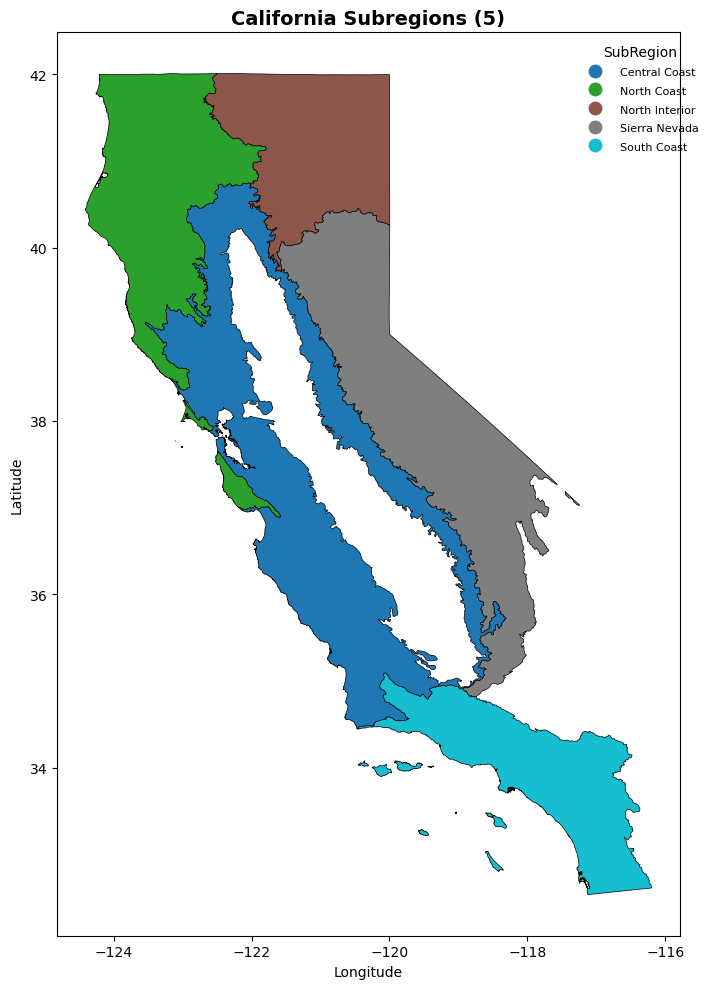

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))
gdf_subregion.plot(
    column='SubRegion', legend=True, cmap='tab10',
    edgecolor='black', linewidth=0.5, ax=ax
)

leg = ax.get_legend()
if leg is not None:
    leg.set_bbox_to_anchor((1.05, 1))
    leg.set_title('SubRegion', prop={'size': 10})
    for text in leg.get_texts():
        text.set_fontsize(8)
    leg.set_frame_on(False)

ax.set_title('California Subregions (5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 5. Load Reference Weather Grid

Extract the unique (lon, lat) pairs from any single day of the veg-filtered weather data.
This defines the set of grid cells that need a subregion assignment.

In [8]:
reference_weather = pd.read_parquet(WEATHER_REF_PATH)
reference_weather = reference_weather[reference_weather['day'] == '1998-01-01']
reference_grid    = (
    reference_weather[['lon', 'lat']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Reference weather grid cells: {len(reference_grid):,}")
reference_grid.head()

Reference weather grid cells: 14,394


,lon,lat
0,-124.391667,40.441667
1,-124.391667,40.400000
2,-124.350000,40.525000
3,-124.350000,40.483333
4,-124.350000,40.441667


## 6. Spatial Join: Assign Grid Cells to Subregions

Convert the weather grid to a `GeoDataFrame` of `Point` geometries, then use
`gpd.sjoin(..., predicate='within')` to find which subregion polygon each point falls in.
Grid cells outside all polygons receive `NaN` and are labeled `'Unknown'`.

In [9]:
# Convert weather grid to GeoDataFrame
weather_points = gpd.GeoDataFrame(
    reference_grid,
    geometry=gpd.points_from_xy(reference_grid['lon'], reference_grid['lat']),
    crs='EPSG:4326'
)

# Spatial join: each point gets the SubRegion it falls within
joined = gpd.sjoin(weather_points, gdf_subregion, how='left', predicate='within')

# Attach the SubRegion label back to the flat DataFrame
reference_grid['SubRegion'] = joined['SubRegion'].values

print(f"Spatial join complete.")
print(f"SubRegion assignment counts (including NaN):")
print(reference_grid['SubRegion'].value_counts(dropna=False).to_string())

Spatial join complete.
SubRegion assignment counts (including NaN):
SubRegion
Sierra Nevada     3652
Central Coast     3491
North Coast       2355
North Interior    2034
South Coast       1516
NaN               1346


## 7. QA: Missing Assignments & Per-Region Visualization

Grid cells with no subregion match (ocean cells or cells just outside polygon boundaries)
are labeled `'Unknown'` and assigned code `0`. We visualize each subregion individually
to confirm spatial coverage before dropping the unmatched cells.

In [10]:
# Fill NaN with 'Unknown', then map to integer codes for visualization
reference_grid['SubRegion'] = reference_grid['SubRegion'].fillna('Unknown')
reference_grid['SubRegion_num'] = reference_grid['SubRegion'].map(SUBREGION_MAPPING)

missing_pct = (reference_grid['SubRegion'] == 'Unknown').mean() * 100
print(f"Unmatched grid cells ('Unknown'): {(reference_grid['SubRegion'] == 'Unknown').sum():,}"
      f" ({missing_pct:.1f}%)")
print()
print(reference_grid.isnull().mean().mul(100).rename('missing_%').to_string())

Unmatched grid cells ('Unknown'): 1,346 (9.4%)

lon              0.0
lat              0.0
SubRegion        0.0
SubRegion_num    0.0


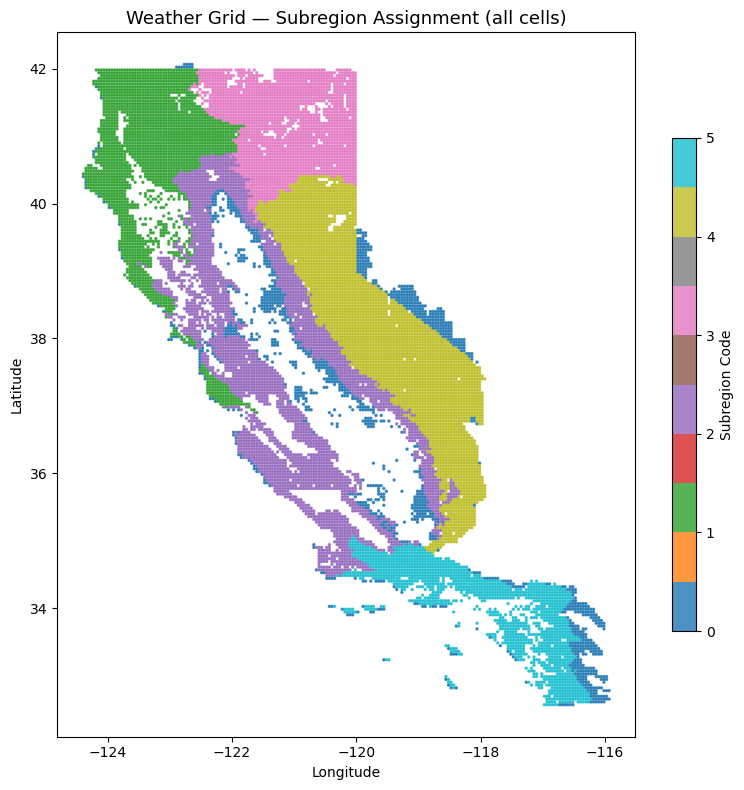

In [11]:
# All-regions overview
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    reference_grid['lon'], reference_grid['lat'],
    c=reference_grid['SubRegion_num'], cmap='tab10', s=2, alpha=0.8
)
fig.colorbar(scatter, ax=ax, label='Subregion Code', shrink=0.7)
ax.set_title('Weather Grid — Subregion Assignment (all cells)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

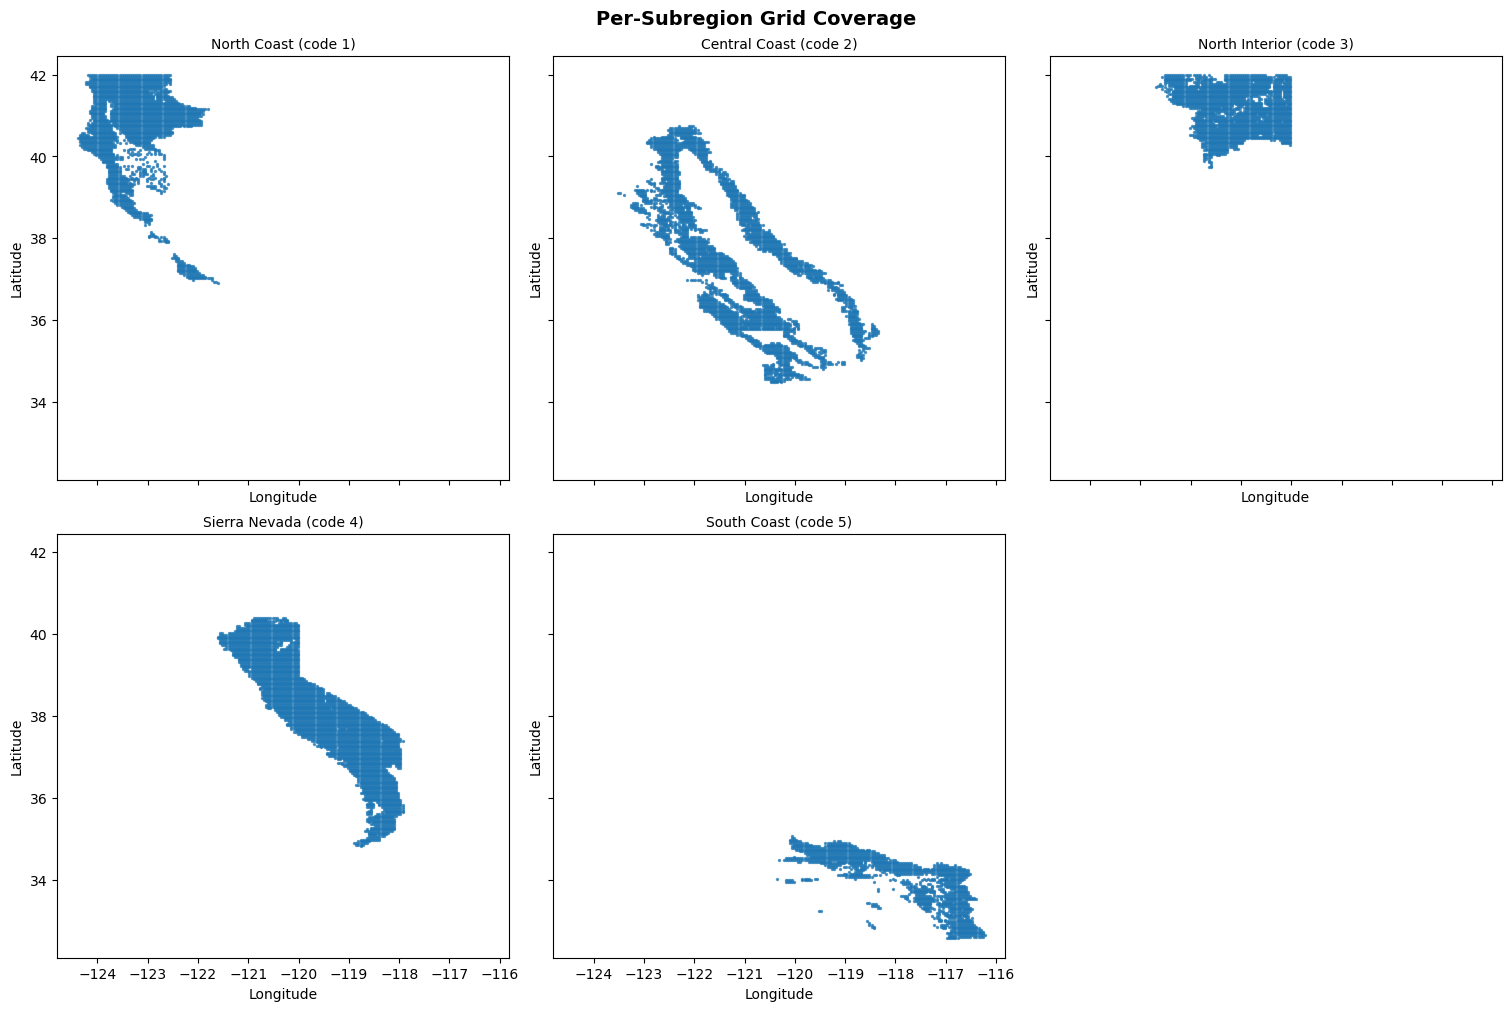

In [12]:
# Per-subregion scatter panel
region_nums = sorted(reference_grid['SubRegion_num'].dropna().unique())
# exclude Unknown (0) from panel
region_nums = [r for r in region_nums if r != 0]

n_cols = 3
n_rows = -(-len(region_nums) // n_cols)   # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows),
                         sharex=True, sharey=True, constrained_layout=True)

inv_map = {v: k for k, v in SUBREGION_MAPPING.items()}
for idx, rnum in enumerate(region_nums):
    ax = axes.flat[idx]
    subset = reference_grid[reference_grid['SubRegion_num'] == rnum]
    ax.scatter(subset['lon'], subset['lat'], s=2, c='tab:blue', alpha=0.7)
    ax.set_title(f"{inv_map[rnum]} (code {rnum})", fontsize=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Hide unused subplots
for idx in range(len(region_nums), len(axes.flat)):
    axes.flat[idx].axis('off')

plt.suptitle('Per-Subregion Grid Coverage', fontsize=14, fontweight='bold')
plt.show()

## 8. Drop 'Unknown' Cells & Finalize Mapping

Grid cells labeled `'Unknown'` are outside all CA subregion polygons
(typically ocean cells or near-boundary points). We drop them here — the
visual QA above confirms the spatial pattern is reasonable.

The `SubRegion_num` helper column is also dropped; the string label is sufficient
for all downstream joins.

In [13]:
n_before = len(reference_grid)
grid_clean = (
    reference_grid[reference_grid['SubRegion'] != 'Unknown']
    .drop(columns=['SubRegion_num'])
    .reset_index(drop=True)
)
n_after = len(grid_clean)

print(f"Before : {n_before:,} grid cells")
print(f"After  : {n_after:,} grid cells")
print(f"Dropped: {n_before - n_after:,} Unknown cells ({(n_before - n_after)/n_before*100:.1f}%)")
print()
print("SubRegion distribution:")
print(grid_clean['SubRegion'].value_counts().to_string())
print()
grid_clean.head()

Before : 14,394 grid cells
After  : 13,048 grid cells
Dropped: 1,346 Unknown cells (9.4%)

SubRegion distribution:
SubRegion
Sierra Nevada     3652
Central Coast     3491
North Coast       2355
North Interior    2034
South Coast       1516



,lon,lat,SubRegion
0,-124.391667,40.441667,North Coast
1,-124.350000,40.525000,North Coast
2,-124.350000,40.483333,North Coast
3,-124.350000,40.441667,North Coast
4,-124.350000,40.400000,North Coast


In [14]:
# Confirm no duplicate lon/lat pairs in the final mapping
n_dupes = grid_clean[['lon', 'lat']].duplicated().sum()
assert n_dupes == 0, f"Unexpected duplicates: {n_dupes}"
print(f"Unique lon/lat pairs: {len(grid_clean):,} — no duplicates.")

Unique lon/lat pairs: 13,048 — no duplicates.


### Save Phase A Output

Write the subregion lookup table to Parquet. Phase B loads this file
to inner-join every weather variable.

In [15]:
mapping_path = os.path.join(
    SUBREGION_CLEAN_DIR, 'lon_lat_pair_weather_match_subregion.parquet'
)
grid_clean.to_parquet(mapping_path, index=False)

print(f"Saved -> {mapping_path}")
print(f"File size : {os.path.getsize(mapping_path) / 1e6:.2f} MB")
print(f"Shape     : {grid_clean.shape[0]:,} rows × {grid_clean.shape[1]} cols")
print(f"Columns   : {list(grid_clean.columns)}")

# Free Phase A memory
del reference_weather, reference_grid, weather_points, joined, gdf_subregion
gc.collect()

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Subregion_Data\lon_lat_pair_weather_match_subregion.parquet
File size : 0.01 MB
Shape     : 13,048 rows × 3 cols
Columns   : ['lon', 'lat', 'SubRegion']


76

---

# Phase B: Apply Subregion Filter to Weather Data

Inner-join every veg-filtered weather parquet with the subregion lookup table
(built in Phase A). This removes grid cells outside the 5 CA subregions.
Per-year missing rates are tracked before and after the filter to monitor
data quality across the full pipeline.

## 9. Load Subregion Mapping & Discover Weather Files

Reload the Phase A parquet and list all weather variable files to be processed.
Verify that the mapping has no duplicate grid cells (each cell must appear exactly once).

In [16]:
subregion = pd.read_parquet(mapping_path)
filter_keys = subregion[['lon', 'lat']].drop_duplicates()

assert subregion[['lon', 'lat']].duplicated().sum() == 0, \
    "Duplicate lon/lat pairs in subregion mapping!"

print(f"Subregion mapping : {subregion.shape[0]:,} rows")
print(f"SubRegion labels  : {sorted(subregion['SubRegion'].unique())}")
print()
subregion.head()

Subregion mapping : 13,048 rows
SubRegion labels  : ['Central Coast', 'North Coast', 'North Interior', 'Sierra Nevada', 'South Coast']



,lon,lat,SubRegion
0,-124.391667,40.441667,North Coast
1,-124.350000,40.525000,North Coast
2,-124.350000,40.483333,North Coast
3,-124.350000,40.441667,North Coast
4,-124.350000,40.400000,North Coast


In [17]:
weather_files = sorted([f for f in os.listdir(WEATHER_VEG_DIR) if f.endswith('.parquet')])
print(f"Weather files to process: {len(weather_files)}")
for f in weather_files:
    print(f"  {f}")

Weather files to process: 11
  dead_fuel_moisture_1000h.parquet
  dead_fuel_moisture_100h.parquet
  max_air_temperature.parquet
  max_relative_humidity.parquet
  min_air_temperature.parquet
  min_relative_humidity.parquet
  precipitation_amount.parquet
  specific_humidity.parquet
  surface_downwelling_shortwave_flux.parquet
  wind_from_direction.parquet
  wind_speed.parquet


## 10. Apply Subregion Filter (Batch)

For each weather variable:
1. Load the veg-filtered parquet
2. Compute per-year missing rates **before** filtering
3. Inner-join with the subregion filter keys
4. Compute per-year missing rates **after** filtering
5. Save the filtered parquet and log the results

> The weather variable name is inferred from the 4th column (index 3) of each file,
> following the convention established in earlier pipeline notebooks.

In [18]:
missing_rate_before = {}
missing_rate_after  = {}
log_messages        = []

log_messages.append("Task: Apply subregion filter to veg-filtered weather data")
log_messages.append(f"Processing started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
log_messages.append(f"Filter grid cells : {len(filter_keys):,}")
log_messages.append("")

for file in tqdm(weather_files, desc="Applying subregion filter"):
    log_messages.append("=" * 50)

    in_path  = os.path.join(WEATHER_VEG_DIR,      file)
    out_path = os.path.join(WEATHER_SUBREGION_DIR, file)

    dat = pd.read_parquet(in_path)
    weather_var = dat.columns[3]   # infer variable name from column position
    log_messages.append(f"File     : {file}")
    log_messages.append(f"Variable : {weather_var}")
    log_messages.append(f"Before   : {dat.shape[0]:,} rows")

    # --- Missing rate BEFORE ---
    for yr, rate in dat.groupby('year')[weather_var].apply(lambda x: x.isnull().mean()).items():
        missing_rate_before.setdefault(yr, {})[weather_var] = rate

    # --- Apply filter ---
    dat_filtered = dat.merge(filter_keys, on=['lon', 'lat'], how='inner')
    reduction_pct = (1 - dat_filtered.shape[0] / dat.shape[0]) * 100
    log_messages.append(f"After    : {dat_filtered.shape[0]:,} rows  "
                        f"(reduced {reduction_pct:.1f}%)")

    dat_filtered.to_parquet(out_path, index=False)
    log_messages.append(f"Saved -> {out_path}")

    # --- Missing rate AFTER ---
    for yr, rate in dat_filtered.groupby('year')[weather_var].apply(lambda x: x.isnull().mean()).items():
        missing_rate_after.setdefault(yr, {})[weather_var] = rate

    del dat, dat_filtered
    gc.collect()

log_messages.append("")
log_messages.append(f"Pipeline finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Done.")

Applying subregion filter: 100%|██████████| 11/11 [12:43<00:00, 69.37s/it]

Done.


## 11. Missing Rate Summary

Review per-year missing rates across all weather variables before and after
the subregion filter. The rates should be similar — a large divergence would
suggest the subregion polygons exclude too many valid grid cells.

In [19]:
missing_df_before = (
    pd.DataFrame.from_dict(missing_rate_before, orient='index')
    .sort_index()
)
missing_df_before.index.name = 'year'

print(f"Missing rate BEFORE subregion filter  ({missing_df_before.shape[1]} variables):")
missing_df_before

Missing rate BEFORE subregion filter  (11 variables):


,dead_fuel_moisture_1000hr,dead_fuel_moisture_100hr,max_air_temperature,max_relative_humidity,min_air_temperature,min_relative_humidity,precipitation_amount,specific_humidity,surface_downwelling_shortwave_flux_in_air,wind_from_direction,wind_speed
year,,,,,,,,,,,
1994,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
1995,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
1996,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
1997,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
1998,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
1999,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
2000,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899,0.023899
2001,0.020371,0.020371,0.000417,0.020371,0.000417,0.020371,0.746026,0.020371,0.020371,0.021800,0.020371
2002,0.020371,0.020371,0.000417,0.020371,0.000417,0.020372,0.817490,0.020371,0.020371,0.021884,0.020371


In [20]:
missing_df_after = (
    pd.DataFrame.from_dict(missing_rate_after, orient='index')
    .sort_index()
)
missing_df_after.index.name = 'year'

print(f"Missing rate AFTER subregion filter  ({missing_df_after.shape[1]} variables):")
missing_df_after

Missing rate AFTER subregion filter  (11 variables):


,dead_fuel_moisture_1000hr,dead_fuel_moisture_100hr,max_air_temperature,max_relative_humidity,min_air_temperature,min_relative_humidity,precipitation_amount,specific_humidity,surface_downwelling_shortwave_flux_in_air,wind_from_direction,wind_speed
year,,,,,,,,,,,
1994,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
1995,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
1996,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
1997,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
1998,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
1999,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
2000,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602,0.003602
2001,0.000996,0.000996,0.000307,0.000996,0.000307,0.000996,0.733842,0.000996,0.000996,0.002501,0.000996
2002,0.000996,0.000996,0.000307,0.000996,0.000307,0.000997,0.807864,0.000996,0.000996,0.002599,0.000996


## 12. Save Missing Rate CSVs

Persist both missing-rate tables to `Summary_Data/Missing_Rate/`
for downstream QA dashboards and reports.

In [21]:
before_csv = os.path.join(SUMMARY_DIR, 'weather_data_w_veg_filter.csv')
after_csv  = os.path.join(SUMMARY_DIR, 'weather_data_w_veg_subregion_filter.csv')

missing_df_before.to_csv(before_csv)
missing_df_after.to_csv(after_csv)

print(f"Saved: {before_csv}")
print(f"Saved: {after_csv}")

Saved: E:\zcao\CA_Wildfire\Summary_Data\Missing_Rate\weather_data_w_veg_filter.csv
Saved: E:\zcao\CA_Wildfire\Summary_Data\Missing_Rate\weather_data_w_veg_subregion_filter.csv


## 13. Save Processing Log

Write the accumulated log messages to a `.txt` file for reproducibility and audit.

In [22]:
log_path = os.path.join(
    LOG_DIR, 'filter_weather_veg_data_w_subregion_log.txt'
)
with open(log_path, 'w') as f:
    f.write('\n'.join(log_messages))

print(f"Log saved to: {log_path}")
print()
print('\n'.join(log_messages[-20:]))   # preview last 20 lines

Log saved to: E:\zcao\CA_Wildfire\Logs\Clean_Extended_Data\filter_weather_veg_data_w_subregion_log.txt

File     : surface_downwelling_shortwave_flux.parquet
Variable : surface_downwelling_shortwave_flux_in_air
Before   : 157,622,658 rows
After    : 142,966,936 rows  (reduced 9.3%)
Saved -> E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_SubRegion_Filter\surface_downwelling_shortwave_flux.parquet
File     : wind_from_direction.parquet
Variable : wind_from_direction
Before   : 157,622,658 rows
After    : 142,966,936 rows  (reduced 9.3%)
Saved -> E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_SubRegion_Filter\wind_from_direction.parquet
File     : wind_speed.parquet
Variable : wind_speed
Before   : 157,622,658 rows
After    : 142,966,936 rows  (reduced 9.3%)
Saved -> E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_SubRegion_Filter\wind_speed.parquet

Pipeline finished: 2026-03-17 14:32:42


## 14. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Load Data | Read shapefile + summary CSV from `Subregion_Data/` | 5 CA subregion polygons |
| A | Inspect | Print CRS, columns, subregion labels | Re-project to EPSG:4326 if needed |
| A | Visualize | Plot subregion polygon map | Geographic extents confirmed |
| A | Weather Grid | Extract unique (lon, lat) from veg-filtered reference | ~14k grid cells |
| A | Spatial Join | `gpd.sjoin(..., predicate='within')` | Each point → subregion label or NaN |
| A | QA | Per-region scatter panels + missing rate check | ~few % unmatched (ocean/border) |
| A | Drop Unknown | Remove cells outside all polygons | Final combustible + in-region grid |
| A | Save | `lon_lat_pair_weather_match_subregion.parquet` | Phase A output |
| B | Load Mapping | Reload Phase A parquet, list weather files | Verified no duplicate keys |
| B | Batch Filter | Inner-join each weather parquet × subregion keys | ~9% row reduction per file |
| B | Missing Rates | Track NaN rates before & after per variable/year | Stable across filter |
| B | Save CSVs | Two missing-rate summary tables | QA audit trail |
| B | Save Log | Processing timestamps + per-file stats | Reproducibility record |